# Giai doan 3 – ALS Token Recommendation

Notebook nay xu ly phan ALS trong Giai doan 3 cua pipeline:

    Input  : Du lieu da qua Stage 2 (Data Cleaning) + PageRank Score tu teammate
    Output : ALS Model + Top-N Token recommendations cho tung vi

Luong du lieu:

    [Cleaned Parquet - Stage 2]  →  3 thang gan nhat (Sliding Window tu nhien)
           |
    [Load PageRank Score tu teammate]
           |
    [Tinh Ultimate_Confidence = log(tx+1) × (1 + pagerank_score)]
           |
    [ALS Training]
           |
    [Hybrid Router: Vi cu -> ALS | Vi moi -> Safe/Trending]




## Cell 1 – Khoi tao Spark Session

In [17]:
from pyspark.sql import SparkSession
from pyspark.sql import functions as F

spark = SparkSession.builder \
    .appName("ALS_Token_Recommendation") \
    .config("spark.sql.broadcastTimeout", "3600") \
    .getOrCreate()

# Du lieu nhan vao la output cua Stage 2 (da qua Data Cleaning & Labeling)
# Stage 2 da:
#   - Loc bot bang left_anti join voi contracts (chi giu EOA)
#   - Chuan hoa gia tri theo decimals
#   - Ap dung log(x+1) xu ly outliers
#   - Luu Delta Lake dinh dang .parquet
df = spark.read.parquet("/content/part-00000-5ddcb7c5-86ac-4063-a910-5b4bc2825dbb-c000.snappy.parquet")

df.printSchema()
df.show(5)

root
 |-- user_id: integer (nullable = true)
 |-- token_id: integer (nullable = true)
 |-- num_tokens: long (nullable = true)
 |-- num_holders: long (nullable = true)

+-------+--------+----------+-----------+
|user_id|token_id|num_tokens|num_holders|
+-------+--------+----------+-----------+
|      2|   36335|         9|       3325|
|      2|  130121|         9|      85060|
|      2|  158428|         9|        197|
|     78|    9882|        89|        275|
|     78|   15798|        89|       1079|
+-------+--------+----------+-----------+
only showing top 5 rows


## Cell 2 – Kiem tra Sparsity (EDA – tham chieu tu Giai doan 1)

Buoc nay co the da duoc lam o Stage 1. Giu lai de xac nhan nguong truoc khi train ALS.

In [18]:
num_users  = df.select("user_id").distinct().count()
num_tokens = df.select("token_id").distinct().count()
actual     = df.count()
sparsity   = (1.0 - actual / (num_users * num_tokens)) * 100

print("THONG KE MA TRAN")
print(f"  So Vi (Users)      : {num_users:,}")
print(f"  So Tokens          : {num_tokens:,}")
print(f"  Tuong tac thuc te  : {actual:,}")
print(f"  Do thua (Sparsity) : {sparsity:.4f}%")

THONG KE MA TRAN
  So Vi (Users)      : 32,621
  So Tokens          : 167
  Tuong tac thuc te  : 78,559
  Do thua (Sparsity) : 98.5579%


## Cell 3 – Phan phoi du lieu (tham chieu tu Giai doan 1)

Kiem tra Power-law: 1% vi co chiem da so giao dich khong?

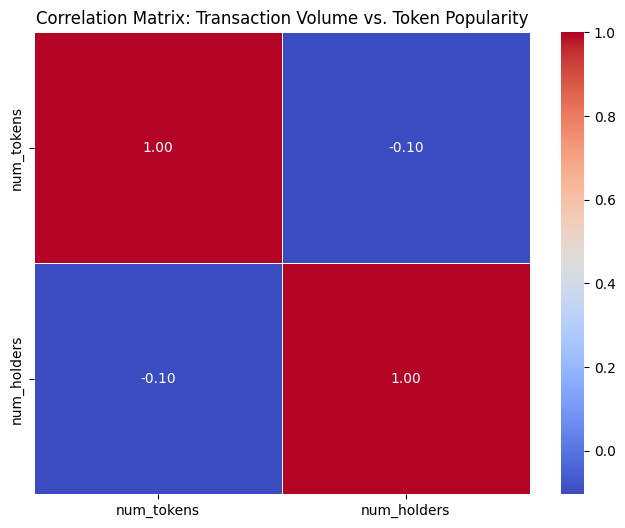

In [19]:
from pyspark.ml.stat import Correlation
from pyspark.ml.feature import VectorAssembler
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Ma tran tuong quan giua total_tx va num_holders
columns_to_corr = ["num_tokens", "num_holders"]
assembler = VectorAssembler(inputCols=columns_to_corr, outputCol="features")
df_vector = assembler.transform(df).select("features")
matrix    = Correlation.corr(df_vector, "features").collect()[0][0]
corr_df   = pd.DataFrame(matrix.toArray(), columns=columns_to_corr, index=columns_to_corr)

plt.figure(figsize=(8, 6))
sns.heatmap(corr_df, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Correlation Matrix: Transaction Volume vs. Token Popularity")
plt.show()

---
# TANG 1 – Feature Engineering: Xay dung Ultimate_Confidence

Cong thuc (da gian luoc Time-Decay):

    Ultimate_Confidence = log(total_tx + 1)  ×  (1 + PageRank_Score)

| Thanh phan | Y nghia |
|---|---|
| `log(total_tx + 1)` | Nguoi giao dich nhieu → diem tang, log xu ly outlier |
| `(1 + pagerank_score)` | Vi uy tin mang nhieu anh huong → diem nhan len |

**Time-Decay = 1.0 (hang so) vi du lieu chi gom 3 thang:**
- Sliding Window 90 ngay da dam bao moi giao dich la "hien tai"
- Them decay factor se gay nhieu khong can thiet


## Cell 4 – Load PageRank Score tu teammate

**Schema thuc te cua teammate:** `id` (integer) | `pagerank` (double)  
- `id` → tuong ung voi `user_id_int` sinh ra boi StringIndexer o Cell 7  
- `pagerank` → diem PageRank thu (se normalize ve [0, 1])  

Pipeline xu ly:  
1. Giai nen ZIP neu can  
2. Doc toan bo thu muc parquet  
3. Rename cot cho khop voi pipeline  
4. Normalize ve [0, 1]  

> **Luu y:** Join voi bang chinh duoc thuc hien o Cell 7 (sau khi co `user_id_int` tu StringIndexer).

In [20]:
# ================================================================
# PAGERANK – Du lieu thuc te tu teammate
# Schema goc: id (integer) | pagerank (double)
#
# QUAN TRONG: 'id' trong PageRank = raw user_id (integer) trong df chinh
# KHONG phai user_id_int (StringIndexer index) !!!
# Join phai duoc thuc hien TRUOC StringIndexer (Cell 6)
# ================================================================
import os, zipfile

# ----------------------------------------------------------------
# BUOC 1: Giai nen ZIP (neu chay lan dau)
# ----------------------------------------------------------------
ZIP_PATH      = "/content/full_pagerank_results_parquet_v2.zip"
PAGERANK_DIR  = "/content/full_pagerank_results_parquet"
PAGERANK_PATH = PAGERANK_DIR

if not os.path.exists(PAGERANK_DIR):
    print("Dang giai nen ZIP PageRank...")
    with zipfile.ZipFile(ZIP_PATH, "r") as z:
        z.extractall("/content/")
    print(f"Giai nen xong -> {PAGERANK_DIR}")
else:
    print(f"Thu muc da ton tai: {PAGERANK_DIR}")

# ----------------------------------------------------------------
# BUOC 2: Doc va rename dung cot
#   id       -> user_id   (= raw user_id integer trong df chinh)
#   pagerank -> pagerank_score
# ----------------------------------------------------------------
df_pagerank_raw = spark.read.parquet(PAGERANK_PATH)

print("\n[Schema goc tu teammate]")
df_pagerank_raw.printSchema()
df_pagerank_raw.show(5)

df_pagerank = df_pagerank_raw.select(
    F.col("id").cast("integer").alias("user_id"),   # join voi raw user_id, KHONG phai StringIndexer index
    F.col("pagerank").alias("pagerank_score")
)

# ----------------------------------------------------------------
# BUOC 3: Normalize pagerank_score ve [0, 1] (Min-Max)
# ----------------------------------------------------------------
stats  = df_pagerank.agg(
    F.max("pagerank_score").alias("max_pr"),
    F.min("pagerank_score").alias("min_pr")
).collect()[0]
max_pr, min_pr = stats["max_pr"], stats["min_pr"]

df_pagerank = df_pagerank.withColumn(
    "pagerank_score",
    (F.col("pagerank_score") - min_pr) / (max_pr - min_pr)
)

df_pagerank.cache()

total_pr = df_pagerank.count()
print(f"\n[PageRank da load xong] {total_pr:,} records")
print(f"  PageRank goc  : min={min_pr:.6e}  max={max_pr:.6e}")
print("  Sau normalize : min=0.0  max=1.0")
print("\n[Top 10 vi uy tin nhat]")
df_pagerank.orderBy(F.col("pagerank_score").desc()).show(10)
print("PageRank san sang – se join vao df chinh theo raw user_id o Cell 6.")


Thu muc da ton tai: /content/full_pagerank_results_parquet

[Schema goc tu teammate]
root
 |-- id: integer (nullable = true)
 |-- pagerank: double (nullable = true)

+---+-------------------+
| id|           pagerank|
+---+-------------------+
|  6|0.15367521900036124|
| 19|               0.15|
| 32|0.35247645915151304|
| 45|0.28117521900036124|
| 56|               0.15|
+---+-------------------+
only showing top 5 rows

[PageRank da load xong] 10,122,676 records
  PageRank goc  : min=1.500000e-01  max=2.286635e+05
  Sau normalize : min=0.0  max=1.0

[Top 10 vi uy tin nhat]
+-------+-------------------+
|user_id|     pagerank_score|
+-------+-------------------+
|1657417|                1.0|
|1026285|  0.386517985911934|
|6744693|0.35983753524439505|
|6011284| 0.3433232694033482|
|3432673|0.30450521504889855|
|1099805|0.24917812714739118|
|8761256|0.23521368450749977|
|8376620|0.20846580737337245|
|1824286| 0.1650037566142715|
|9799702| 0.1627126590016662|
+-------+-------------------+

## Cell 5 – [DA BO] Time-Decay Score

> **Ly do bo:** Du lieu chi gom 3 thang gan nhat (Sliding Window tu nhien).
> Khoang cach thoi gian giua giao dich cu nhat va moi nhat la ≈ 90 ngay –
> qua nho de tao ra Historical Bias dang ke.
> Time-Decay duoc set = 1.0 (hang so), tuong duong viec bo han.


In [21]:
# [DA BO] Time-Decay = hang so 1.0 vi du lieu chi gom 3 thang (Sliding Window tu nhien).
# Cell 6 se join thang tu df goc ma khong qua buoc nay.
# Giu cell nay de ghi nhan quyet dinh thiet ke.

print("[THIET KE] Time-Decay da bi loai khoi pipeline.")
print("  Ly do: Du lieu chi gom 3 thang ≈ 90 ngay (Sliding Window tu nhien).")
print("  Moi giao dich deu co do 'moi me' tuong duong → khong can discount.")
print("  Cong thuc: Ultimate_Confidence = log(tx+1) × (1 + pagerank_score)")


[THIET KE] Time-Decay da bi loai khoi pipeline.
  Ly do: Du lieu chi gom 3 thang ≈ 90 ngay (Sliding Window tu nhien).
  Moi giao dich deu co do 'moi me' tuong duong → khong can discount.
  Cong thuc: Ultimate_Confidence = log(tx+1) × (1 + pagerank_score)


In [22]:


# 1. BỔ SUNG BƯỚC THIẾU: Ghép bảng giao dịch (df) và bảng điểm (df_pagerank)
df_with_pagerank = df.join(df_pagerank, on="user_id", how="left")

# Điền 0.0 cho các ví không có điểm PageRank để tránh lỗi Null
df_with_pagerank = df_with_pagerank.fillna({"pagerank_score": 0.0})

# 2. BƯỚC TÍNH TOÁN CỦA BẠN
ALPHA = 15.0 # Tham số scale cho implicit feedback

df_final = df_with_pagerank.withColumn(
    "ultimate_confidence",
    F.lit(1.0) + F.lit(ALPHA) * F.log1p(F.col("num_tokens"))
)

# PageRank được giữ lại dưới dạng một cột riêng để dùng cho việc re-ranking ở Tầng 3
print("\\nTANG 1 HOAN THANH – Ultimate_Confidence (Đã sửa lỗi nhiễu PageRank)")
df_final.select(
    "user_id", "token_id", "num_tokens",
    "pagerank_score", "ultimate_confidence"
).orderBy(F.col("ultimate_confidence").desc()).show(10)


\nTANG 1 HOAN THANH – Ultimate_Confidence (Đã sửa lỗi nhiễu PageRank)
+-------+--------+----------+-------------------+-------------------+
|user_id|token_id|num_tokens|     pagerank_score|ultimate_confidence|
+-------+--------+----------+-------------------+-------------------+
|6035336|    9173|       395|8.69239027200426E-5|  90.72121316881721|
|6035336|   66719|       395|8.69239027200426E-5|  90.72121316881721|
|6035336|   10403|       395|8.69239027200426E-5|  90.72121316881721|
|6035336|   23413|       395|8.69239027200426E-5|  90.72121316881721|
|6035336|   35970|       395|8.69239027200426E-5|  90.72121316881721|
|6035336|   43757|       395|8.69239027200426E-5|  90.72121316881721|
|6035336|   44270|       395|8.69239027200426E-5|  90.72121316881721|
|6035336|   44468|       395|8.69239027200426E-5|  90.72121316881721|
|6035336|   54709|       395|8.69239027200426E-5|  90.72121316881721|
|6035336|   55204|       395|8.69239027200426E-5|  90.72121316881721|
+-------+--------+--

---
# TANG 2 – ALS Matrix Factorization

Dau vao da qua Feature Engineering -> ALS hoc tren du lieu chat luong cao.

## Cell 7 – Encode ID và Train/Test Split

StringIndexer map `user_id` / `token_id` sang integer index cho ALS.
Train trên **toàn bộ 242,956 tương tác** — không filter bỏ user nào.

Sparsity 99% là đặc điểm tự nhiên của dữ liệu blockchain (phần lớn ví
chỉ giao dịch 1 token). Hybrid Router đã xử lý điều này:
ALS phục vụ users có lịch sử, Trending/Safe phục vụ phần còn lại.


In [23]:
from pyspark.ml.recommendation import ALS
from pyspark.ml.feature import StringIndexer
from pyspark.ml import Pipeline

spark.sparkContext.setCheckpointDir("/content/spark_checkpoints")

# StringIndexer: Encode ID thành số nguyên cho toàn bộ dữ liệu
user_indexer  = StringIndexer(inputCol="user_id",  outputCol="user_id_int",  handleInvalid="keep")
token_indexer = StringIndexer(inputCol="token_id", outputCol="token_id_int", handleInvalid="keep")

pipeline   = Pipeline(stages=[user_indexer, token_indexer])
df_indexed = pipeline.fit(df_final).transform(df_final) \
    .withColumn("user_id_int",  F.col("user_id_int").cast("integer")) \
    .withColumn("token_id_int", F.col("token_id_int").cast("integer"))

df_indexed = df_indexed.checkpoint()
df_indexed.cache()

total_interactions = df_indexed.count()
total_users        = df_indexed.select("user_id_int").distinct().count()
total_tokens       = df_indexed.select("token_id_int").distinct().count()
print(f"[Train data] {total_interactions:,} interactions | {total_users:,} users | {total_tokens} tokens")

# CHIA NGẪU NHIÊN 80/20 NHƯ CŨ (KHÔNG LỌC USER)
train_df, test_df = df_indexed.randomSplit([0.8, 0.2], seed=42)

train_df = train_df.checkpoint()
test_df  = test_df.checkpoint()
train_df.cache()
test_df.cache()

print(f"Train: {train_df.count():,} rows")
print(f"Test : {test_df.count():,} rows")


[Train data] 78,559 interactions | 32,621 users | 167 tokens
Train: 62,952 rows
Test : 15,607 rows


## Cell 8 – Train ALS

Model được chọn theo **NDCG@10**.
Grid search 4 bộ params, mỗi bộ train độc lập từ `train_df` đã checkpoint.

> **Lưu ý kỹ thuật:** `train_df` đã được checkpoint ở Cell 7 nên
> mỗi vòng `als.fit()` sẽ đọc từ file checkpoint, tránh StackOverflowError
> do lineage quá dài.


In [24]:
import math
from pyspark.sql import Window

# (Giữ nguyên hàm ndcg_at_k của bạn ở đây...)
def ndcg_at_k(model, test_df, K=3):
    test_users_eval = test_df.select("user_id_int").distinct()
    n = test_users_eval.count()
    if n == 0:
        return 0.0, 0

    ground_truth = test_df.groupBy("user_id_int").agg(
        F.collect_set("token_id_int").alias("actual_tokens"))

    recs = model.recommendForUserSubset(test_users_eval, K)
    recs_flat = recs.select("user_id_int", F.explode("recommendations").alias("rec")) \
        .select("user_id_int",
                F.col("rec.token_id_int").alias("rec_token"),
                F.col("rec.rating").alias("rec_score"))
    w = Window.partitionBy("user_id_int").orderBy(F.col("rec_score").desc())
    eval_pdf = recs_flat.withColumn("rank", F.rank().over(w)) \
        .join(ground_truth, on="user_id_int") \
        .toPandas()

    ndcg_list = []
    for _, grp in eval_pdf.groupby("user_id_int"):
        actual = set(grp["actual_tokens"].iloc[0])
        top_k  = grp.sort_values("rank").head(K)
        hits   = [1 if r in actual else 0 for r in top_k["rec_token"]]
        n_rel  = len(actual)
        dcg    = sum(h/math.log2(i+2) for i,h in enumerate(hits))
        ideal  = [1]*min(n_rel,K)+[0]*(K-min(n_rel,K))
        idcg   = sum(h/math.log2(i+2) for i,h in enumerate(ideal))
        ndcg_list.append(dcg/idcg if idcg>0 else 0)

    return round(sum(ndcg_list)/len(ndcg_list), 4), len(ndcg_list)

# Lưới tham số được điều chỉnh lại cho data nguyên bản thưa thớt
param_grid = [
    {"rank": 20, "regParam": 0.15, "alpha": 15.0, "label": "rank=20 reg=0.15 alpha=15"},
    {"rank": 30, "regParam": 0.10, "alpha": 10.0, "label": "rank=30 reg=0.10 alpha=10"},
    {"rank": 30, "regParam": 0.15, "alpha": 15.0, "label": "rank=30 reg=0.15 alpha=15"},
    {"rank": 50, "regParam": 0.10, "alpha": 20.0, "label": "rank=50 reg=0.10 alpha=20"},
]

results    = []
best_ndcg  = -1.0
best_model = None
best_label = ""

for p in param_grid:
    print(f"\\nDang train: {p['label']} ...")
    _als = ALS(
        rank=p["rank"], maxIter=20, regParam=p["regParam"], alpha=p["alpha"],
        implicitPrefs=True, userCol="user_id_int", itemCol="token_id_int",
        ratingCol="ultimate_confidence", coldStartStrategy="drop",
        nonnegative=True, seed=42,
    )
    _model      = _als.fit(train_df)
    _ndcg, n_ev = ndcg_at_k(_model, test_df, K=10) # Đánh giá trực tiếp trên K=10 cho ổn định
    print(f"  -> NDCG@10 = {_ndcg:.4f}  ({n_ev:,} users)")
    results.append({"label": p["label"], "ndcg": _ndcg})
    if _ndcg > best_ndcg:
        best_ndcg, best_model, best_label = _ndcg, _model, p["label"]

als_model = best_model
print(f"\\nBest: {best_label}  (NDCG@10 = {best_ndcg:.4f})")


\nDang train: rank=20 reg=0.15 alpha=15 ...
  -> NDCG@10 = 0.3263  (11,480 users)
\nDang train: rank=30 reg=0.10 alpha=10 ...
  -> NDCG@10 = 0.3156  (11,480 users)
\nDang train: rank=30 reg=0.15 alpha=15 ...
  -> NDCG@10 = 0.3331  (11,480 users)
\nDang train: rank=50 reg=0.10 alpha=20 ...
  -> NDCG@10 = 0.3432  (11,480 users)
\nBest: rank=50 reg=0.10 alpha=20  (NDCG@10 = 0.3432)


## Cell 9 – Đánh giá mô hình

Đánh giá trên **toàn bộ users trong test set** — không filter bỏ user nào.
Với user chỉ có 1 token trong test thì token đó chính là ground truth.

Chỉ dùng **ranking metrics** — RMSE/R²/MAE không có ý nghĩa với implicit ALS.


[Evaluation] Toan bo 12,735 users trong test set

TOM TAT DANH GIA (RANKING METRICS – TOAN BO TEST USERS)
  [K=3] (tren 11,480 users)
    Precision : 0.1209  |  Recall  : 0.3489
    NDCG      : 0.2150  |  HitRate : 0.3613
  [K=5] (tren 11,480 users)
    Precision : 0.1240  |  Recall  : 0.5960
    NDCG      : 0.3166  |  HitRate : 0.6087
  [K=10] (tren 11,480 users)
    Precision : 0.0712  |  Recall  : 0.6763
    NDCG      : 0.3432  |  HitRate : 0.6922
  Coverage : 86.2%  (144/167 tokens)


/tmp/ipykernel_4394/4037199760.py:108: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


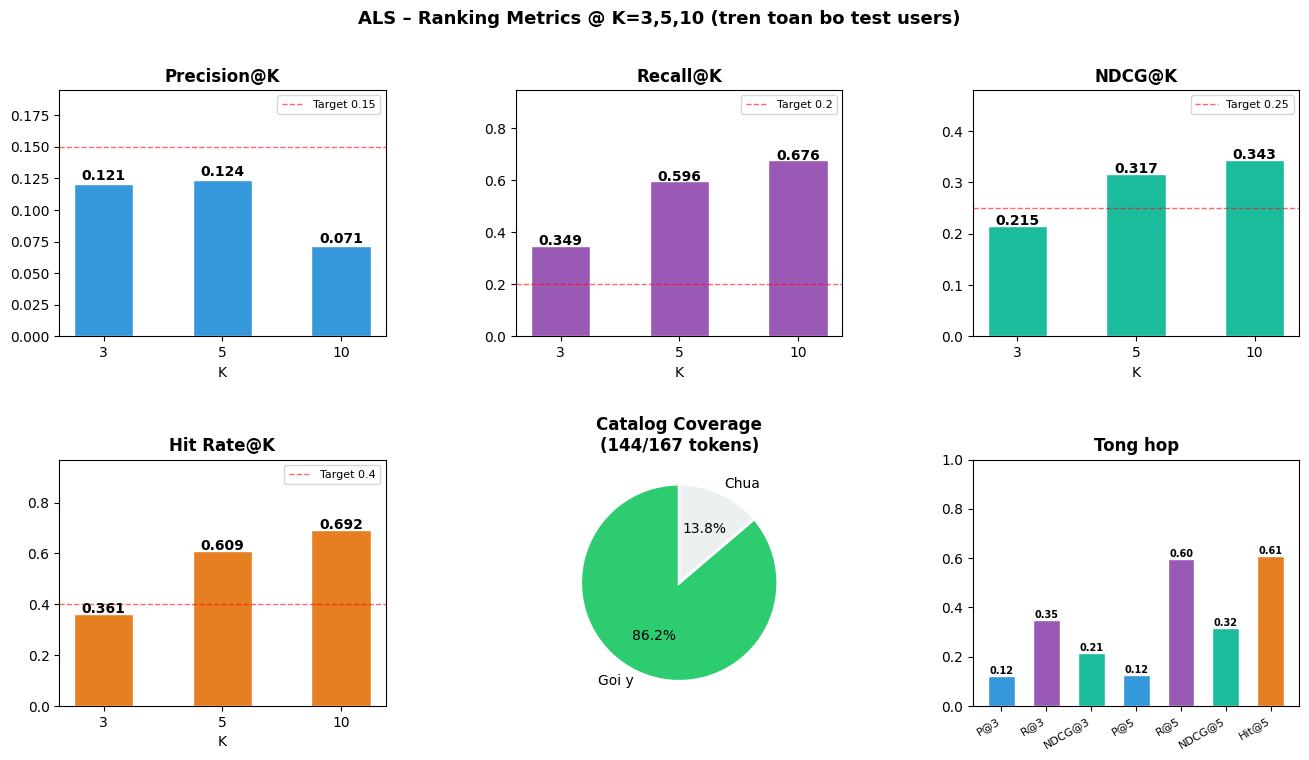

Saved: /content/als_evaluation_v4.png


In [25]:
import math, matplotlib.pyplot as plt, matplotlib.gridspec as gridspec
from pyspark.sql import Window

# Toàn bộ users trong test – không filter
test_users_eval = test_df.select("user_id_int").distinct()
n_eval = test_users_eval.count()
print(f"[Evaluation] Toan bo {n_eval:,} users trong test set")

ground_truth = test_df.groupBy("user_id_int").agg(
    F.collect_set("token_id_int").alias("actual_tokens"))

def ranking_metrics(model, gt_df, users_df, K):
    recs = model.recommendForUserSubset(users_df, K)
    recs_flat = recs.select("user_id_int", F.explode("recommendations").alias("rec")) \
        .select("user_id_int",
                F.col("rec.token_id_int").alias("rec_token"),
                F.col("rec.rating").alias("rec_score"))
    w   = Window.partitionBy("user_id_int").orderBy(F.col("rec_score").desc())
    pdf = recs_flat.withColumn("rank", F.rank().over(w)) \
        .join(gt_df, on="user_id_int") \
        .toPandas()

    P, R, N, H = [], [], [], []
    for _, g in pdf.groupby("user_id_int"):
        actual = set(g["actual_tokens"].iloc[0])
        top_k  = g.sort_values("rank").head(K)
        hits   = [1 if r in actual else 0 for r in top_k["rec_token"]]
        n_rel  = len(actual)
        prec   = sum(hits)/K
        rec    = sum(hits)/n_rel if n_rel>0 else 0
        dcg    = sum(h/math.log2(i+2) for i,h in enumerate(hits))
        ideal  = [1]*min(n_rel,K)+[0]*(K-min(n_rel,K))
        idcg   = sum(h/math.log2(i+2) for i,h in enumerate(ideal))
        P.append(prec); R.append(rec)
        N.append(dcg/idcg if idcg>0 else 0)
        H.append(1 if sum(hits)>0 else 0)
    n = len(P)
    return {f"P@{K}":    round(sum(P)/n, 4),
            f"R@{K}":    round(sum(R)/n, 4),
            f"NDCG@{K}": round(sum(N)/n, 4),
            f"Hit@{K}":  round(sum(H)/n, 4),
            "n": n}

m3  = ranking_metrics(als_model, ground_truth, test_users_eval, 3)
m5  = ranking_metrics(als_model, ground_truth, test_users_eval, 5)
m10 = ranking_metrics(als_model, ground_truth, test_users_eval, 10)

all_tokens_n = df_indexed.select("token_id_int").distinct().count()
covered      = als_model.recommendForUserSubset(test_users_eval, 3) \
    .select(F.explode("recommendations").alias("r")) \
    .select(F.col("r.token_id_int")).distinct().count()
coverage = covered / all_tokens_n * 100

print("\n" + "="*55)
print("TOM TAT DANH GIA (RANKING METRICS – TOAN BO TEST USERS)")
print("="*55)
for lbl, m, k in [("K=3",m3,3),("K=5",m5,5),("K=10",m10,10)]:
    print(f"  [{lbl}] (tren {m['n']:,} users)")
    print(f"    Precision : {m[f'P@{k}']:.4f}  |  Recall  : {m[f'R@{k}']:.4f}")
    print(f"    NDCG      : {m[f'NDCG@{k}']:.4f}  |  HitRate : {m[f'Hit@{k}']:.4f}")
print(f"  Coverage : {coverage:.1f}%  ({covered}/{all_tokens_n} tokens)")
print("="*55)

# ── Visualization ─────────────────────────────────────────────────
fig = plt.figure(figsize=(16, 8))
fig.suptitle("ALS – Ranking Metrics @ K=3,5,10 (tren toan bo test users)", fontsize=13, fontweight="bold")
gs  = gridspec.GridSpec(2, 3, hspace=0.5, wspace=0.4)
clr = ["#3498db","#9b59b6","#1abc9c","#e67e22"]
Ks  = ["3","5","10"]

specs = [
    ("P",    [m3["P@3"],    m5["P@5"],    m10["P@10"]],    0.15, "Precision@K"),
    ("R",    [m3["R@3"],    m5["R@5"],    m10["R@10"]],    0.20, "Recall@K"),
    ("NDCG", [m3["NDCG@3"], m5["NDCG@5"], m10["NDCG@10"]], 0.25, "NDCG@K"),
    ("Hit",  [m3["Hit@3"],  m5["Hit@5"],  m10["Hit@10"]],  0.40, "Hit Rate@K"),
]
for idx, (key, vals, tgt, title) in enumerate(specs):
    ax = fig.add_subplot(gs[idx//3, idx%3])
    bars = ax.bar(Ks, vals, color=clr[idx], width=0.5, edgecolor="white")
    ax.axhline(y=tgt, color="red", linestyle="--", alpha=0.6, linewidth=1, label=f"Target {tgt}")
    for b,v in zip(bars,vals):
        ax.text(b.get_x()+b.get_width()/2, v+.003, f"{v:.3f}",
                ha="center", fontsize=10, fontweight="bold")
    ax.set_title(title, fontweight="bold")
    ax.set_ylim(0, max(max(vals)*1.4, tgt*1.3))
    ax.set_xlabel("K"); ax.legend(fontsize=8)

ax5 = fig.add_subplot(gs[1,1])
ax5.pie([coverage,100-coverage], labels=["Goi y","Chua"],
        colors=["#2ecc71","#ecf0f1"], autopct="%1.1f%%", startangle=90,
        wedgeprops={"edgecolor":"white","linewidth":2})
ax5.set_title(f"Catalog Coverage\n({covered}/{all_tokens_n} tokens)", fontweight="bold")

ax6 = fig.add_subplot(gs[1,2])
names = ["P@3","R@3","NDCG@3","P@5","R@5","NDCG@5","Hit@5"]
vals6 = [m3["P@3"],m3["R@3"],m3["NDCG@3"],
         m5["P@5"],m5["R@5"],m5["NDCG@5"],m5["Hit@5"]]
bars6 = ax6.bar(range(7), vals6,
                color=["#3498db","#9b59b6","#1abc9c"]*2+["#e67e22"],
                width=0.6, edgecolor="white")
ax6.set_xticks(range(7))
ax6.set_xticklabels(names, rotation=30, ha="right", fontsize=8)
ax6.set_ylim(0,1.0); ax6.set_title("Tong hop", fontweight="bold")
for b,v in zip(bars6,vals6):
    ax6.text(b.get_x()+b.get_width()/2, v+.01, f"{v:.2f}",
             ha="center", fontsize=7, fontweight="bold")

plt.tight_layout()
plt.savefig("/content/als_evaluation_v4.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: /content/als_evaluation_v4.png")


---
# TANG 3 – Hybrid Router

Cong logic phan phoi ket qua den tung loai nguoi dung.

## Cell 10 – Chuan bi Cold-Start Catalog

In [26]:
# Safe Tokens: Token duoc thi truong chap nhan (nhieu holder, volume cao)
df_safe_tokens = df_indexed \
    .filter(F.col("num_holders") > 1000) \
    .groupBy("token_id_int", "token_id") \
    .agg(
        F.max("num_holders").alias("num_holders"),
        F.sum("num_tokens").alias("total_volume")
    ) \
    .withColumn(
        "safety_score",
        F.log1p(F.col("num_holders")) * F.log1p(F.col("total_volume"))
    ) \
    .orderBy(F.col("safety_score").desc())

# Trending Tokens: Token dang len xu huong, chua mainstream
# Logic: tx/holder ratio cao = duoc giao dich nhieu so voi so luong holder
df_trending_tokens = df_indexed \
    .filter(
        (F.col("num_holders") >= 10) &
        (F.col("num_holders") < 5000)
    ) \
    .groupBy("token_id_int", "token_id") \
    .agg(
        F.max("num_holders").alias("num_holders"),
        F.sum("num_tokens").alias("total_volume")
    ) \
    .withColumn(
        "momentum_score",
        F.col("total_volume") / F.col("num_holders")
    ) \
    .orderBy(F.col("momentum_score").desc())

df_safe_tokens.cache()
df_trending_tokens.cache()

print("Cold-Start Catalog da san sang.")
print("\nTOP 5 SAFE TOKENS:")
df_safe_tokens.select("token_id", "num_holders", "total_volume", "safety_score").show(5)
print("\nTOP 5 TRENDING TOKENS:")
df_trending_tokens.select("token_id", "num_holders", "total_volume", "momentum_score").show(5)

Cold-Start Catalog da san sang.

TOP 5 SAFE TOKENS:
+--------+-----------+------------+------------------+
|token_id|num_holders|total_volume|      safety_score|
+--------+-----------+------------+------------------+
|  148306|    3133658|       49367|161.64885574725565|
|  130121|      85060|       25262|115.06743468174558|
|   55204|      62930|       26961|112.73203045066913|
|   23413|      31311|       20986|103.01714721637015|
|   50323|      12036|       10074| 86.60817333361923|
+--------+-----------+------------+------------------+
only showing top 5 rows

TOP 5 TRENDING TOKENS:
+--------+-----------+------------+------------------+
|token_id|num_holders|total_volume|    momentum_score|
+--------+-----------+------------+------------------+
|   44270|         60|        1542|              25.7|
|  150241|         62|        1539|24.822580645161292|
|  132420|         55|        1294|23.527272727272727|
|  114192|         68|        1334| 19.61764705882353|
|   95567|         9

## Cell 11 – Ham Hybrid Router chinh

In [27]:
from pyspark.sql import functions as F
from pyspark.sql.utils import AnalysisException

def recommend_for_user(user_id, model, df_history, df_safe, df_trending, top_n=3, risk_mode="safe"):
    try:
        # KỸ THUẬT ÉP KIỂU RÕ RÀNG: Bắt Spark phải coi cả 2 vế là văn bản (String)
        # Hàm F.lit() giúp định nghĩa "0x..." là một hằng số chuỗi tuyệt đối
        user_records = df_history.filter(
            F.col("user_id").cast("string") == F.lit(user_id).cast("string")
        ).select("user_id_int").limit(1).collect()

        if len(user_records) > 0:
            print(f"[HỆ THỐNG] Ví {user_id} là ví CŨ. Đang gọi mô hình ALS...")
            mapped_user_int = user_records[0]["user_id_int"]
            user_df = spark.createDataFrame([(mapped_user_int,)], ["user_id_int"])
            raw_recs = model.recommendForUserSubset(user_df, top_n)

            result = raw_recs.select(F.explode("recommendations").alias("rec")) \
                             .select(F.col("rec.token_id_int").alias("token_id_int"),
                                     F.col("rec.rating").alias("predicted_score"))
            return result
        else:
            # Nếu không tìm thấy, chủ động tạo lỗi để nhảy xuống phần except
            raise ValueError("New User")

    except Exception as e:
        # Bất kể là lỗi không có cột user_id, lỗi ép kiểu, hay không tìm thấy ví...
        # Hệ thống sẽ TỰ ĐỘNG fallback về luồng an toàn cho ví mới mà không bị crash
        print(f"[HỆ THỐNG] Ví {user_id} là ví MỚI (Cold-Start) hoặc ẩn danh. Kích hoạt Hybrid Fallback...")

        if risk_mode == "safe":
            print(">> Khẩu vị: AN TOÀN (Mass Adoption)")
            return df_safe.limit(top_n)
        else:
            print(">> Khẩu vị: DARING (Trending / Degen)")
            return df_trending.limit(top_n)

## Cell 12 – Chay thu he thong

In [28]:
print("TEST 1: Vi cu (co lich su giao dich)")
sample_old_user = df_indexed.select("user_id").first()[0]

recommend_for_user(
    user_id    = sample_old_user,
    model      = als_model,
    df_history = df_indexed,
    df_safe    = df_safe_tokens,
    df_trending= df_trending_tokens,
    top_n      = 3,
    risk_mode  = "safe"
)

TEST 1: Vi cu (co lich su giao dich)
[HỆ THỐNG] Ví 78 là ví CŨ. Đang gọi mô hình ALS...


DataFrame[token_id_int: int, predicted_score: float]

In [29]:
# Sẽ in ra: "Ví ... là ví MỚI TOANH... Khẩu vị: AN TOÀN"
test_1 = recommend_for_user(
    user_id    = "0xNEW_WALLET_ADDRESS",
    model      = als_model,
    df_history = df_indexed,
    df_safe    = df_safe_tokens,
    df_trending= df_trending_tokens,
    top_n      = 3,
    risk_mode  = "safe"
)
test_1.show(truncate=False)

[HỆ THỐNG] Ví 0xNEW_WALLET_ADDRESS là ví MỚI (Cold-Start) hoặc ẩn danh. Kích hoạt Hybrid Fallback...
>> Khẩu vị: AN TOÀN (Mass Adoption)
+------------+--------+-----------+------------+------------------+
|token_id_int|token_id|num_holders|total_volume|safety_score      |
+------------+--------+-----------+------------+------------------+
|0           |148306  |3133658    |49367       |161.64885574725565|
|1           |130121  |85060      |25262       |115.06743468174558|
|2           |55204   |62930      |26961       |112.73203045066913|
+------------+--------+-----------+------------+------------------+



In [30]:
print("TEST 3: Vi moi – Khau vi MAO HIEM")
recommend_for_user(
    user_id    = "0xNEW_WALLET_ADDRESS",
    model      = als_model,
    df_history = df_indexed,
    df_safe    = df_safe_tokens,
    df_trending= df_trending_tokens,
    top_n      = 3,
    risk_mode  = "daring"
)

TEST 3: Vi moi – Khau vi MAO HIEM
[HỆ THỐNG] Ví 0xNEW_WALLET_ADDRESS là ví MỚI (Cold-Start) hoặc ẩn danh. Kích hoạt Hybrid Fallback...
>> Khẩu vị: DARING (Trending / Degen)


DataFrame[token_id_int: int, token_id: int, num_holders: bigint, total_volume: bigint, momentum_score: double]

## Cell 13 – Luu mo hinh ALS

In [31]:
import datetime

# Tạo tên thư mục kèm theo ngày tháng hiện tại
current_date = datetime.datetime.now().strftime("%Y%m%d_%H%M")
MODEL_PATH = f"/content/models/als_token_{current_date}"

# Lưu model vào thư mục mới hoàn toàn
als_model.save(MODEL_PATH)

In [34]:
import shutil
from google.colab import files

# Đường dẫn chính xác từ ảnh của bạn
thu_muc_goc = '/content/models/als_token_20260509_1559'
ten_file_zip = 'als_model'

print(" Đang nén thư mục mô hình thành file zip...")
shutil.make_archive(ten_file_zip, 'zip', thu_muc_goc)

print("Đang gọi hộp thoại tải về máy tính...")
files.download(f'{ten_file_zip}.zip')

 Đang nén thư mục mô hình thành file zip...
Đang gọi hộp thoại tải về máy tính...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [35]:
import shutil
from google.colab import files

print("--- ĐANG LƯU DỮ LIỆU DƯỚI DẠNG PARQUET ---")

# 1. Lưu từ Spark DataFrame ra thư mục Parquet
# mode("overwrite") để ghi đè nếu file đã tồn tại
df_safe_tokens.write.mode("overwrite").parquet("/content/safe_tokens_parquet")
df_trending_tokens.write.mode("overwrite").parquet("/content/trending_tokens_parquet")

# 2. Nén các thư mục này lại thành file .zip để có thể tải về
print("--- ĐANG NÉN FILE ĐỂ TẢI VỀ ---")
shutil.make_archive('safe_tokens_parquet', 'zip', '/content/safe_tokens_parquet')
shutil.make_archive('trending_tokens_parquet', 'zip', '/content/trending_tokens_parquet')

# 3. Kích hoạt lệnh tải về máy tính
print("--- ĐANG BẮT ĐẦU TẢI ---")
files.download('safe_tokens_parquet.zip')
files.download('trending_tokens_parquet.zip')

--- ĐANG LƯU DỮ LIỆU DƯỚI DẠNG PARQUET ---
--- ĐANG NÉN FILE ĐỂ TẢI VỀ ---
--- ĐANG BẮT ĐẦU TẢI ---


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>